In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("leads_reales.csv", header=[2])

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
 12  Unnamed: 12           2 non-null      float64
 13  Unnamed: 13           0 non-null      float64
dtypes: float64(3), str(11)
memory usage: 4.9 KB


In [61]:
# Limpiamos la base
df.columns = df.columns.str.strip()
df["Año"] = df["Año"].ffill()
df["Año"] = df["Año"].astype(int)
df = df[:28]
df = df.drop(index=0)
df = df.drop(columns=["Unnamed: 12", "Unnamed: 13"])

In [62]:
# Cambiamos tipos de datos
cols = ["Total","Ilocalizable","No Contesta","D. Incorrectos","Duplicados","Efectivos","Abiertos","Ventas"]
df[cols] = df[cols].replace(",", "", regex=True).astype(int)

df["Conversion"] = df["Conversion"].str.rstrip("%").astype(float)
df["Efectividad de Leads"] = df["Efectividad de Leads"].str.rstrip("%").astype(float)

In [63]:
# Remplazar por valores numéricos la columna de "Mes"
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Mes"] = df["Mes"].str.strip().replace(meses).astype(int)


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 1 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   27 non-null     int64  
 1   Mes                   27 non-null     int64  
 2   Total                 27 non-null     int64  
 3   Ilocalizable          27 non-null     int64  
 4   No Contesta           27 non-null     int64  
 5   D. Incorrectos        27 non-null     int64  
 6   Duplicados            27 non-null     int64  
 7   Efectivos             27 non-null     int64  
 8   Abiertos              27 non-null     int64  
 9   Ventas                27 non-null     int64  
 10  Conversion            27 non-null     float64
 11  Efectividad de Leads  27 non-null     float64
dtypes: float64(2), int64(10)
memory usage: 2.7 KB


In [65]:
# Guardar el DataFrame limpio en un nuevo archivo CSV
df.to_csv("leads_reales_limpio.csv", index=False)

<Axes: xlabel='Efectivos', ylabel='Ventas'>

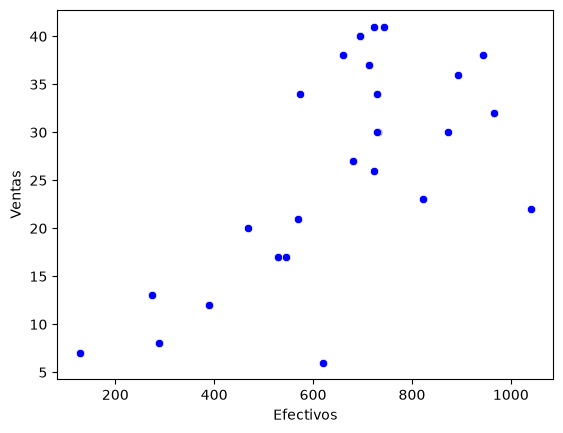

In [66]:
#Imprimimos el scatter plot entre la variable dependiente (ventas) e independiente (efectivos) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Efectivos', y='Ventas', color="blue", data=df)

In [67]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['Efectivos']]
Var_Dep= df['Ventas']

In [68]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [69]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.385
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [70]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Efectivos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03389694]),
 'rank_': np.int64(1),
 'singular_': array([1098.46620339]),
 'intercept_': np.float64(4.385076427863435)}

In [71]:
# Modelo matemático:
# y= 0.03389694(Efectivos)+4.385076427863435

In [72]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.4265904145844708

In [73]:
#Predecimos los valores de total a partir de la variable "efectivos"
y_pred= model.predict(X=df[['Efectivos']])
y_pred

array([17.57098708,  8.72388507, 14.14739588, 13.67283869, 25.40118081,
       23.70633368, 22.89280706, 22.35045598, 32.24836321, 39.63789668,
       37.09562599, 28.89256589, 20.24884554, 29.16374143, 33.94321033,
       23.84192145, 27.90955456, 34.65504613, 27.46889431, 26.75705851,
       27.9434515 , 29.60440169, 29.09594755, 28.58749341, 29.12984449,
       36.3837902 , 28.92646284])

In [74]:
# Insertamos la columna de predicciones en el DataFrame
df.insert(9, 'Predicciones', y_pred)
df

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Predicciones,Ventas,Conversion,Efectividad de Leads
1,2024,2,543,108,33,0,1,389,1,17.570987,12,3.1,72.0
2,2024,3,178,37,13,0,0,128,1,8.723885,7,5.5,72.0
3,2024,4,416,79,46,3,0,288,1,14.147396,8,2.8,69.0
4,2024,5,422,33,100,17,0,274,5,13.672839,13,4.7,65.0
5,2024,6,967,140,173,31,3,620,17,25.401181,6,1.0,64.0
6,2024,7,954,112,251,12,9,570,5,23.706334,21,3.7,60.0
7,2024,8,1409,504,324,17,18,546,22,22.892807,17,3.1,39.0
8,2024,9,1315,431,314,14,26,530,42,22.350456,17,3.2,40.0
9,2024,10,1973,514,606,18,13,822,72,32.248363,23,2.8,42.0
10,2024,11,1562,153,321,44,4,1040,79,39.637897,22,2.1,67.0


<Axes: xlabel='Efectivos', ylabel='Ventas'>

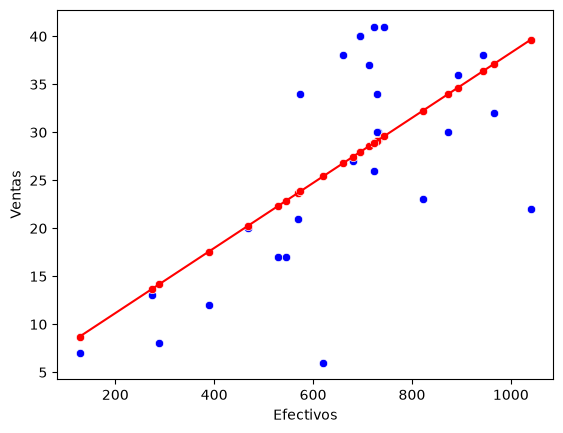

In [83]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='Efectivos', y='Ventas', color="blue", data=df)
sns.scatterplot(x='Efectivos', y='Predicciones', color="red", data=df)
sns.lineplot(x='Efectivos', y='Predicciones', color="red", data=df)

In [84]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.4265904145844708

In [85]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.6531388937924848)

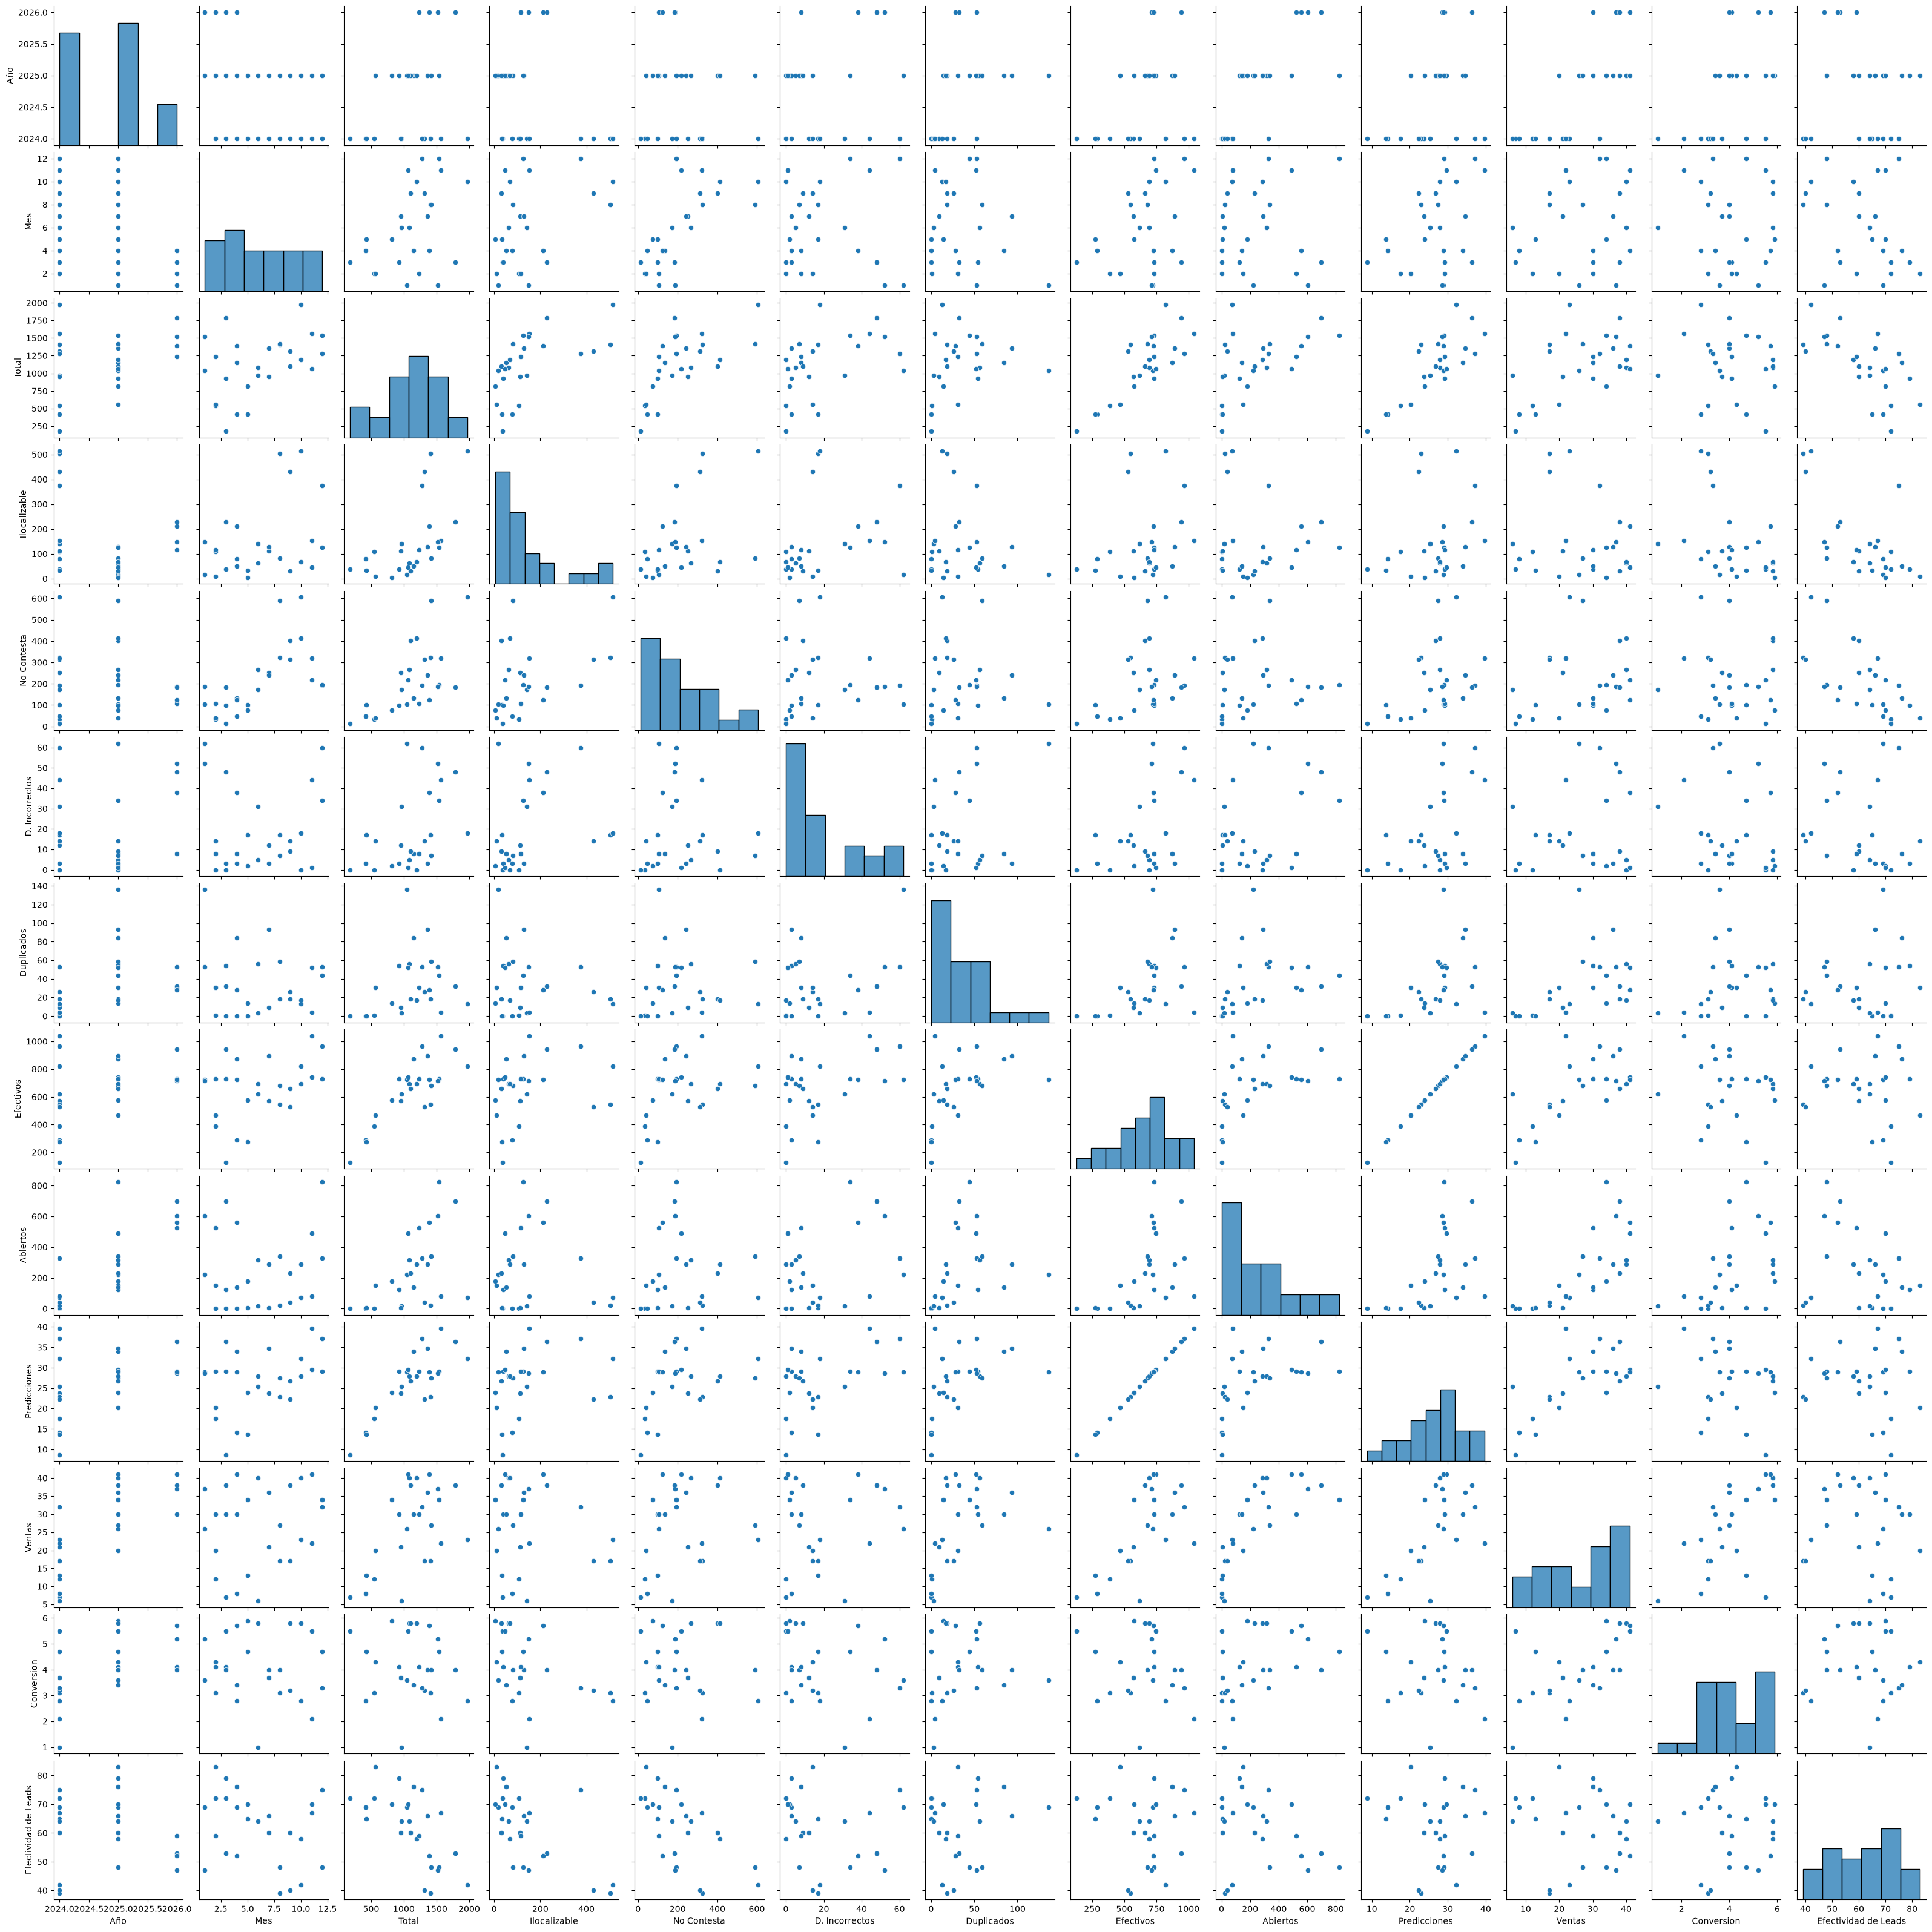

In [86]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df)

In [87]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=df.corr()
Corr_Factors

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Predicciones,Ventas,Conversion,Efectividad de Leads
Año,1.000000,-0.372515,0.344126,-0.288689,-0.098533,0.170772,0.425572,0.386426,0.798667,0.386426,0.747157,0.534219,-0.097187
Mes,-0.372515,1.000000,0.422714,0.395933,0.639890,0.004638,-0.142644,0.361406,0.065623,0.361406,0.195912,-0.071375,-0.306449
Total,0.344126,0.422714,1.000000,0.588069,0.657743,0.451056,0.267892,0.811259,0.526937,0.811259,0.532444,-0.140726,-0.652962
Ilocalizable,-0.288689,0.395933,0.588069,1.000000,0.449274,0.293024,-0.161257,0.244976,-0.052108,0.244976,-0.110980,-0.418180,-0.645683
No Contesta,-0.098533,0.639890,0.657743,0.449274,1.000000,-0.033213,0.001460,0.395866,0.034846,0.395866,0.241042,-0.076721,-0.621549
D. Incorrectos,0.170772,0.004638,0.451056,0.293024,-0.033213,1.000000,0.294281,0.466082,0.378461,0.466082,0.137053,-0.255264,-0.175370
Duplicados,0.425572,-0.142644,0.267892,-0.161257,0.001460,0.294281,1.000000,0.476905,0.358817,0.476905,0.470607,0.095934,0.136588
Efectivos,0.386426,0.361406,0.811259,0.244976,0.395866,0.466082,0.476905,1.000000,0.491656,1.000000,0.653139,-0.145573,-0.112686
Abiertos,0.798667,0.065623,0.526937,-0.052108,0.034846,0.378461,0.358817,0.491656,1.000000,0.491656,0.746696,0.436793,-0.278878
Predicciones,0.386426,0.361406,0.811259,0.244976,0.395866,0.466082,0.476905,1.000000,0.491656,1.000000,0.653139,-0.145573,-0.112686


In [88]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Predicciones,Ventas,Conversion,Efectividad de Leads
Año,1.000000,0.372515,0.344126,0.288689,0.098533,0.170772,0.425572,0.386426,0.798667,0.386426,0.747157,0.534219,0.097187
Mes,0.372515,1.000000,0.422714,0.395933,0.639890,0.004638,0.142644,0.361406,0.065623,0.361406,0.195912,0.071375,0.306449
Total,0.344126,0.422714,1.000000,0.588069,0.657743,0.451056,0.267892,0.811259,0.526937,0.811259,0.532444,0.140726,0.652962
Ilocalizable,0.288689,0.395933,0.588069,1.000000,0.449274,0.293024,0.161257,0.244976,0.052108,0.244976,0.110980,0.418180,0.645683
No Contesta,0.098533,0.639890,0.657743,0.449274,1.000000,0.033213,0.001460,0.395866,0.034846,0.395866,0.241042,0.076721,0.621549
D. Incorrectos,0.170772,0.004638,0.451056,0.293024,0.033213,1.000000,0.294281,0.466082,0.378461,0.466082,0.137053,0.255264,0.175370
Duplicados,0.425572,0.142644,0.267892,0.161257,0.001460,0.294281,1.000000,0.476905,0.358817,0.476905,0.470607,0.095934,0.136588
Efectivos,0.386426,0.361406,0.811259,0.244976,0.395866,0.466082,0.476905,1.000000,0.491656,1.000000,0.653139,0.145573,0.112686
Abiertos,0.798667,0.065623,0.526937,0.052108,0.034846,0.378461,0.358817,0.491656,1.000000,0.491656,0.746696,0.436793,0.278878
Predicciones,0.386426,0.361406,0.811259,0.244976,0.395866,0.466082,0.476905,1.000000,0.491656,1.000000,0.653139,0.145573,0.112686


<Axes: >

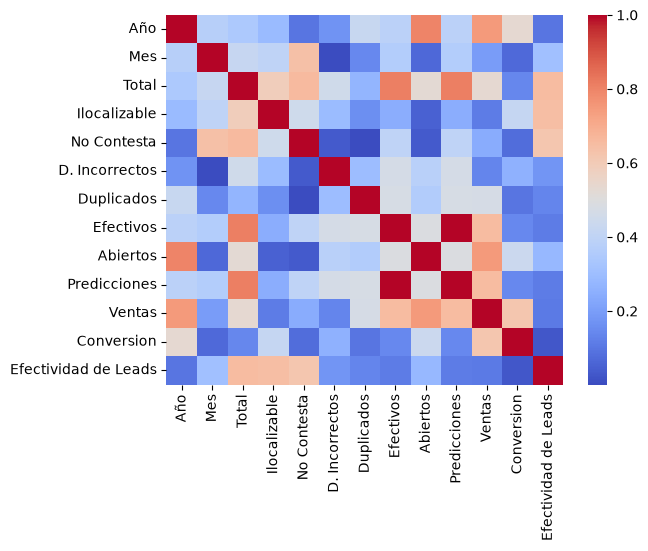

In [89]:
#Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')  
Heat_Map

<Axes: >

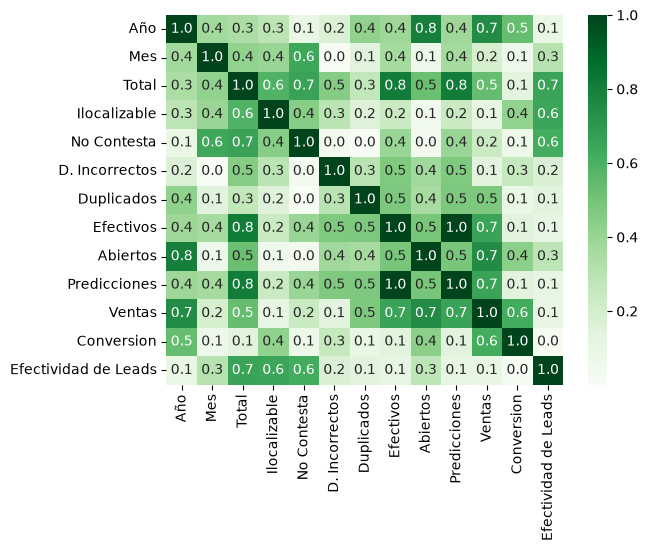

In [90]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map